TASK-1
Personality classification model
The main aim here is to use a set of data to train a model to identify whether a person is intovert or extrovert.


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inside the notebook
%matplotlib inline

1) load the dataset

In [2]:
df = pd.read_csv("personality_dataset.csv")

2. preview of the dataset


In [3]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


3. information about the data set

a) number of rows and colums

In [4]:
df.shape

(2900, 8)

b) name of the coloums

In [5]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='str')

c)info

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


d) statistics info

In [7]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


e) check for missing values     (DATA CLEANING)

In [8]:
df.isnull().sum

<bound method DataFrame.sum of       Time_spent_Alone  Stage_fear  Social_event_attendance  Going_outside  \
0                False       False                    False          False   
1                False       False                    False          False   
2                False       False                    False          False   
3                False       False                    False          False   
4                False       False                    False          False   
...                ...         ...                      ...            ...   
2895             False       False                    False          False   
2896             False       False                    False          False   
2897             False       False                    False          False   
2898             False       False                    False          False   
2899             False       False                    False          False   

      Drained_after_socializing 

f) too check if any row is duplicated           DATA CLEANING 

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2895     True
2896    False
2897    False
2898    False
2899    False
Length: 2900, dtype: bool

# Exploratory data analysis (EDA)  
helps us identify patterns and chck relationship between various data 

1) checking class distribution

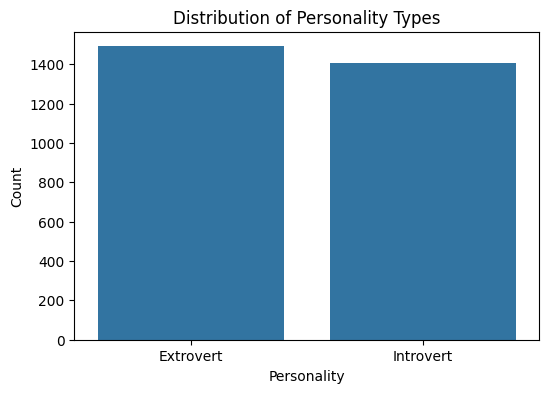

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="Personality", data=df)

plt.title("Distribution of Personality Types")

plt.xlabel("Personality")

plt.ylabel("Count")

plt.show()

the dataset contains roughly equal number of introverts and extroverts meaning that the data is balanced

2) distribution of numerical features

the loop idea was given by ai and this code too

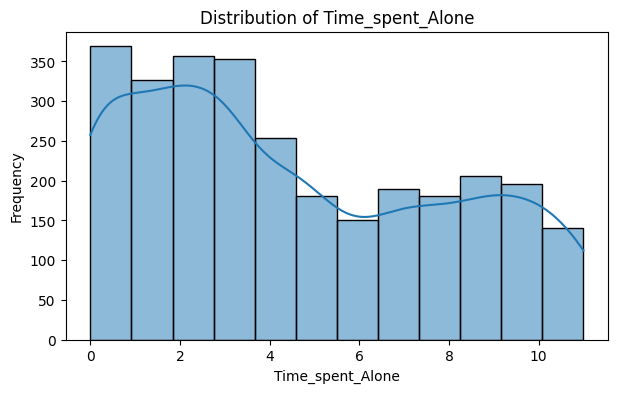

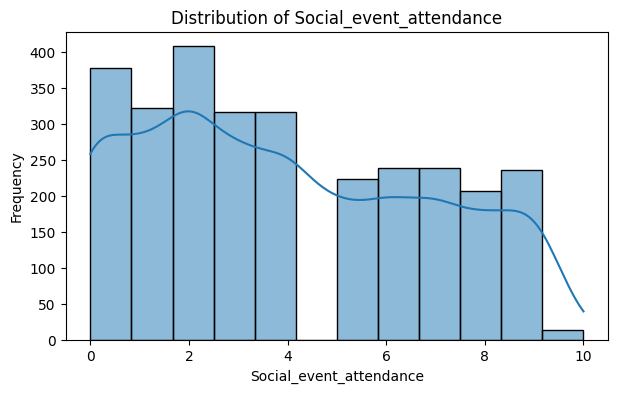

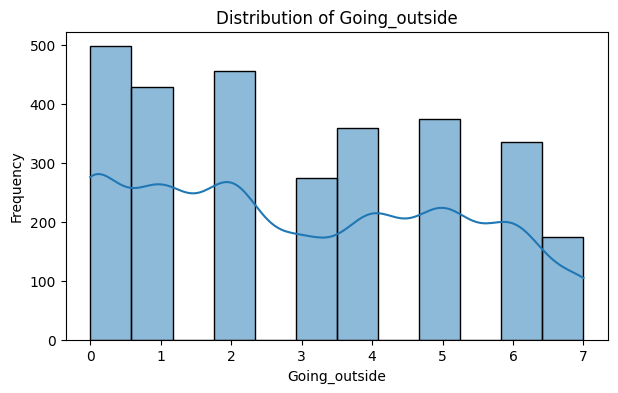

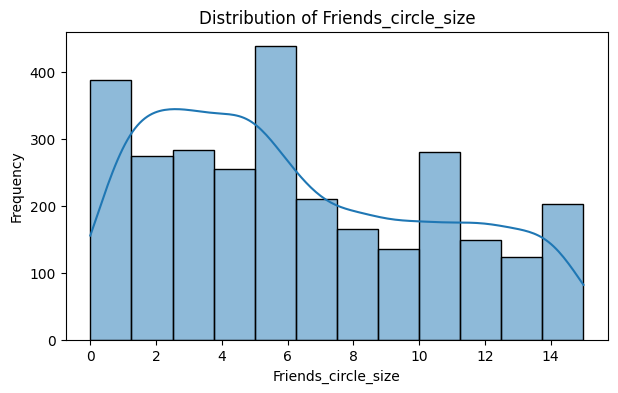

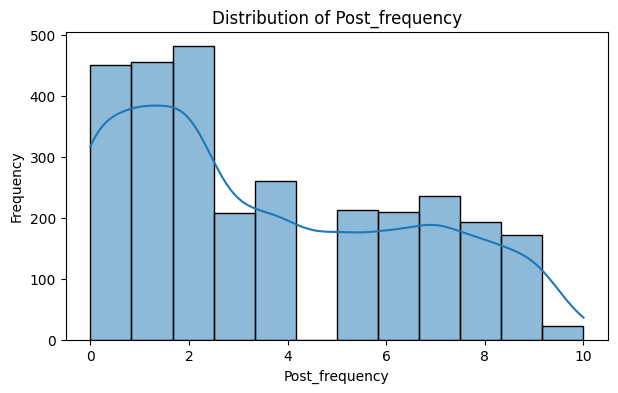

In [11]:
numerical_columns = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency"
]

for column in numerical_columns:
    plt.figure(figsize=(7,4))

    sns.histplot(df[column], bins=12, kde=True)

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

observation-


3)  Distribution of Categorical Features

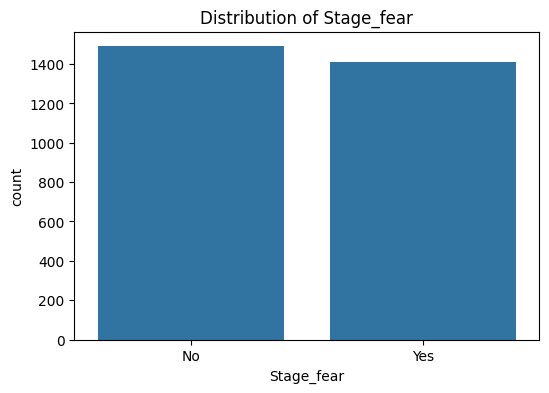

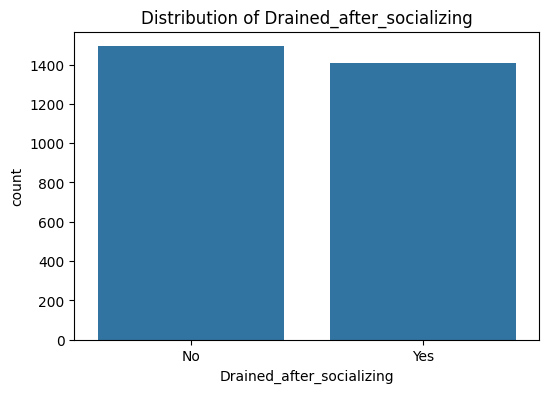

In [12]:
categorical_columns = [
    "Stage_fear",
    "Drained_after_socializing"
]

for column in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(x=column, data=df)

    plt.title(f"Distribution of {column}")

    plt.show()

observation-
by this we get to know that yes and no in these aspects are balanced rather than being dominated by either of them meaning that the data is good

4)  Relationship Between Numerical Features and Personality

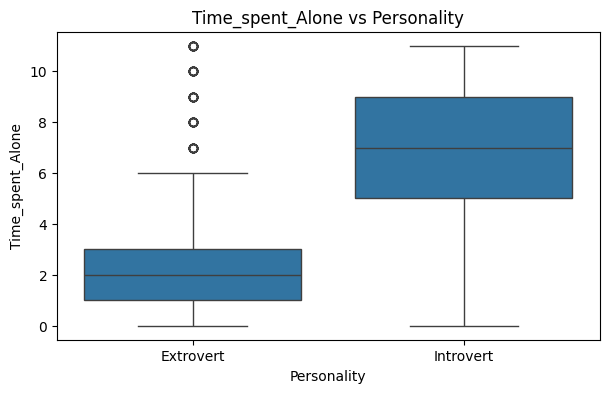

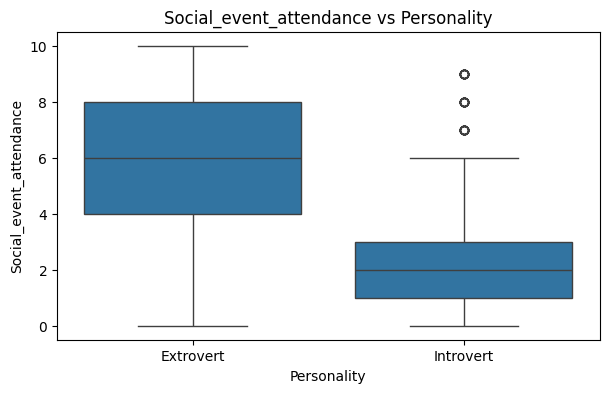

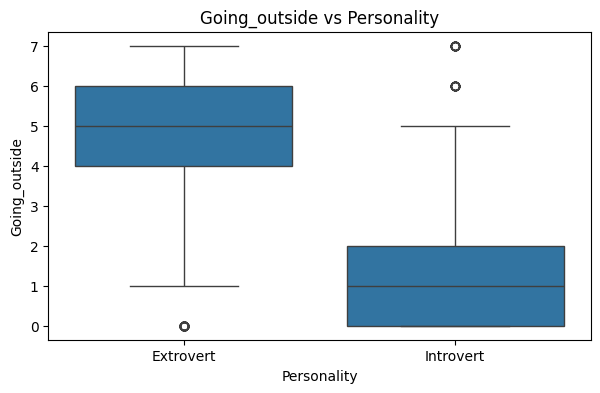

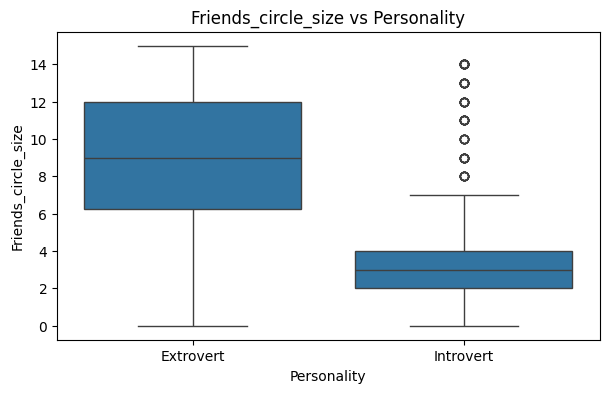

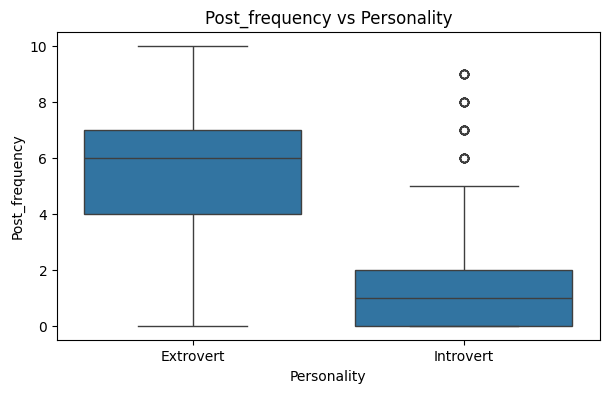

In [13]:
for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x="Personality",
        y=column,
        data=df
    )

    plt.title(f"{column} vs Personality")

    plt.show()

observation-
by making these graphs we get the difference between extroverts and introverts in various numerical aspects

5)  Relationship Between Categorical Features and Personality

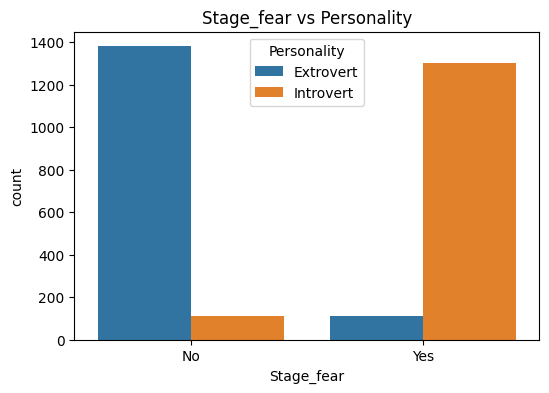

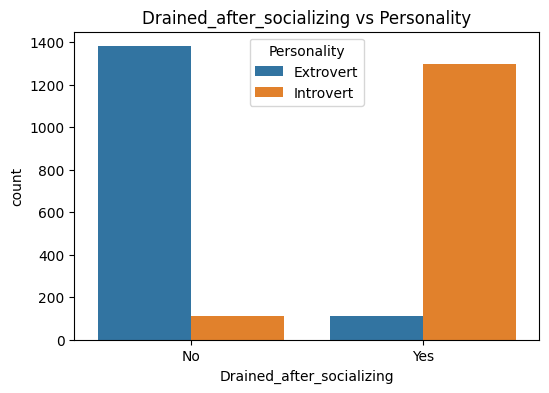

In [14]:
for column in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=column,
        hue="Personality",
        data=df
    )

    plt.title(f"{column} vs Personality")

    plt.show()

observations-
by making these graphs we get the difference between extroverts and introverts in various numerical aspects.

# Data preprocessing
done to convert the categorical to numerical
1) stage fear
2) drained after socializing
3) personality

In [15]:
df["Stage_fear"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [16]:
df["Drained_after_socializing"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [17]:
df["Personality"].unique()

<StringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str

In [18]:
df["Stage_fear"]=df["Stage_fear"].map({
    "Yes":1,
    "No":0
} )

In [19]:
df["Drained_after_socializing"]=df["Drained_after_socializing"].map({
    "Yes":1,
    "No":0
} )

In [20]:
df["Personality"] = df["Personality"].map({
    "Introvert": 0,
    "Extrovert": 1
})

now we verify if teh changes we made were reflected or not!

In [21]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,1
1,9.0,1,0.0,0.0,1,0.0,3.0,0
2,9.0,1,1.0,2.0,1,5.0,2.0,0
3,0.0,0,6.0,7.0,0,14.0,8.0,1
4,3.0,0,9.0,4.0,0,8.0,5.0,1


now everything is in numerical value 

# Feature engeneering
the data has enough features so no feature engeneering was done

# Train Test split(80-20)

In [22]:
X = df.drop("Personality", axis=1)

y = df["Personality"]

x is the features/input
y is the target/ output

In [23]:
X.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,4.0,0,4.0,6.0,0,13.0,5.0
1,9.0,1,0.0,0.0,1,0.0,3.0
2,9.0,1,1.0,2.0,1,5.0,2.0
3,0.0,0,6.0,7.0,0,14.0,8.0
4,3.0,0,9.0,4.0,0,8.0,5.0


In [24]:
y.head()


0    1
1    0
2    0
3    1
4    1
Name: Personality, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2320, 7)
(580, 7)
(2320,)
(580,)


# Model 1-- Logistic regression

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
lr_model = LogisticRegression(random_state=42)

In [30]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
y_pred_lr = lr_model.predict(X_test)

model evaluation

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy of logistic regression=", accuracy_lr)

Accuracy of logistic regression= 0.9241379310344827


In [34]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[258  20]
 [ 24 278]]


In [35]:
cr=classification_report(y_test, y_pred_lr)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       278
           1       0.93      0.92      0.93       302

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



# Observation
1) by using logistic regression model we are able to get 92% accuracy
2) the confusion matrix tells us that 258 introverts were coreectly guesses while 20 were wrongly guesses as extroverts while 278     extroverts were correctly guessed with 24 being guessed wrongly.
3) the classification report tellsus that its balanced.

# Model 2 - Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
dt_model = DecisionTreeClassifier(random_state=42)

In [38]:
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [39]:
y_pred_dt=dt_model.predict(X_test)

model evaluation

In [40]:
accuracy_dt= accuracy_score(y_test, y_pred_dt)
print("Accuracy of decison tree=", accuracy_dt)

Accuracy of decison tree= 0.8810344827586207


In [41]:
cm_dt= confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[252  26]
 [ 43 259]]


In [42]:
cr_dt=classification_report(y_test, y_pred_dt)
print(cr_dt)

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       278
           1       0.91      0.86      0.88       302

    accuracy                           0.88       580
   macro avg       0.88      0.88      0.88       580
weighted avg       0.88      0.88      0.88       580



# observation
using decision tree we get an accuracy of 88 % 

# Model 3- Random forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf=RandomForestClassifier(random_state=42)

In [45]:
rf.fit(X_test,y_test)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [46]:
y_pred_rf=rf.predict(X_test)

model evaluation

In [47]:
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Accuracy of random forest=", accuracy_rf)

Accuracy of random forest= 0.993103448275862


In [48]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
print(cm_rf)

[[277   1]
 [  3 299]]


In [49]:
cr_rf=classification_report(y_test,y_pred_rf)
print (cr_rf)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       278
           1       1.00      0.99      0.99       302

    accuracy                           0.99       580
   macro avg       0.99      0.99      0.99       580
weighted avg       0.99      0.99      0.99       580



# observation 
using random forest gave us an accuracy score of 99%

# Comparing the accuracy of the 3 models

In [50]:
print(f"Logistic Regression={accuracy_lr:.4f}")
print(f"Decision Tree={accuracy_dt:.4f}")
print(f"Random Forest={accuracy_rf:.4f}")

Logistic Regression=0.9241
Decision Tree=0.8810
Random Forest=0.9931


In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})
print(comparison)


                 Model  Accuracy
0  Logistic Regression  0.924138
1        Decision Tree  0.881034
2        Random Forest  0.993103


In [52]:
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.993103
0,Logistic Regression,0.924138
1,Decision Tree,0.881034


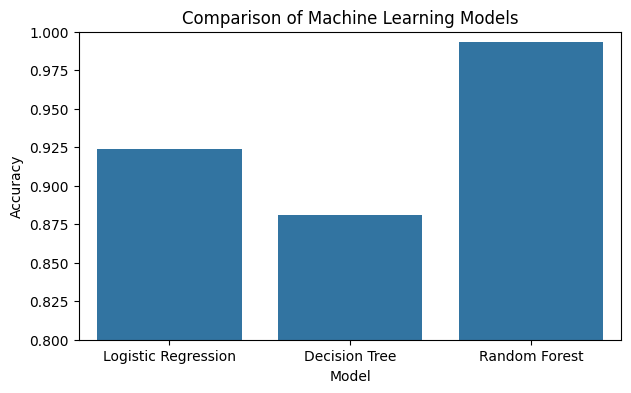

In [53]:

plt.figure(figsize=(7,4))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Comparison of Machine Learning Models")

plt.ylim(0.8, 1.0)

plt.show()

In [54]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model       Random Forest
Accuracy         0.993103
Name: 2, dtype: object


# Conclusion

1) In this project, three classical machine learning models were trained and evaluated for personality classification: Logistic Regression, Decision Tree, and Random Forest.
2) After comparing their performance,the Random Forest achieved the highest accuracy and demonstrated the best overall performance.